## **Plotting marker genes**
This notebook is used to generate visualizations of marker gene expression in dataset A1. We will work with the normalized, log-transformed data that was generated using the preprocessing notebook. 

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

### **1. Import the data**

In [2]:
# Gene expression data
adata = sc.read_h5ad(
    "D1_NABHUG03_JAN26_merged_spaceranger/outs/binned_outputs/square_008um/D1_NABHUG03_JAN26_with_cell_types.h5ad"
)

###  **2. Plot the data**
We will now plot which cells express the following marker genes:
- MARCO
- APOE
- CD163
- CD9
- CTSB
- SPP1

We focus on these markers as they were differentially expressed between the core and the periphery of the tumor. 

In [3]:
coords = adata.obsm["spatial"]
gene_list=["MARCO", "APOE", "CD163", "CD9", "CTSB", "SPP1"]

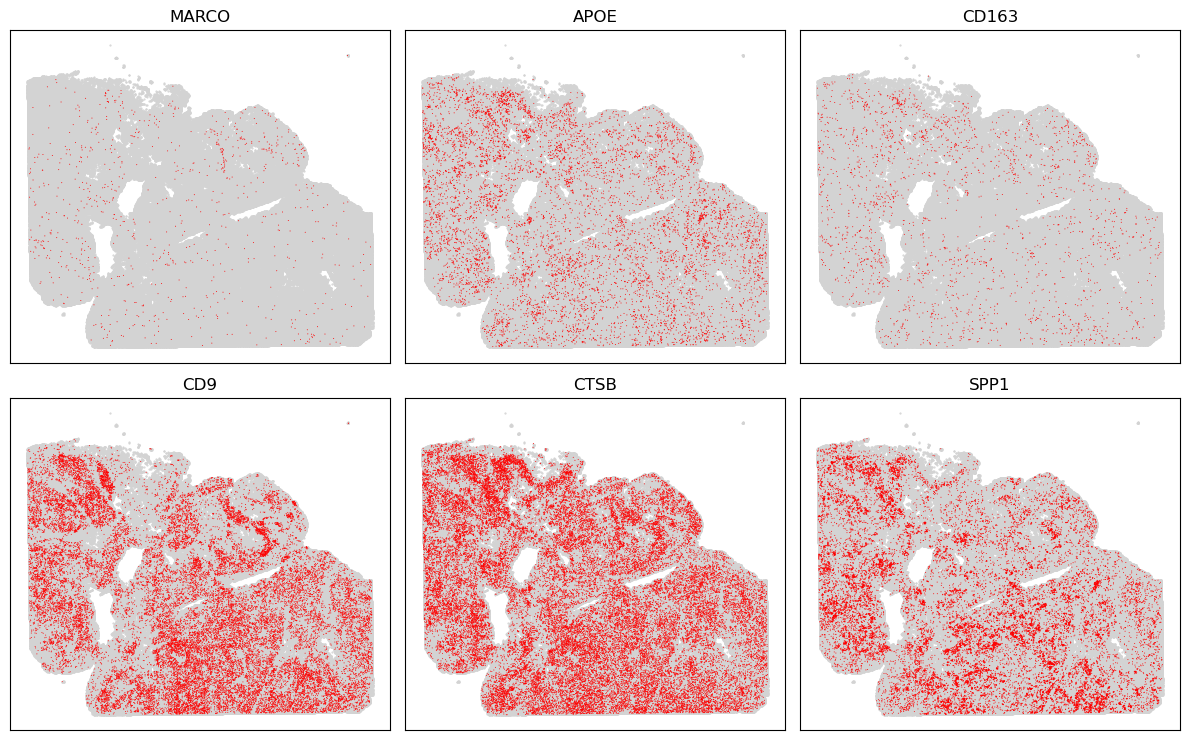

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
axes = axes.flatten()

cmap = ListedColormap(["lightgray", "red"])
for i, gene in enumerate(gene_list):

    expr = adata[:, gene].X

    if hasattr(expr, "toarray"):
        expr = expr.toarray().flatten()
    else:
        expr = expr.flatten()

    threshold = np.quantile(expr, 0.9)
    high = expr > threshold

    # background (ALL cells in gray)
    axes[i].scatter(
        coords[:, 0],
        coords[:, 1],
        c="lightgray",
        s=0.3
    )

    # foreground (HIGH expression in red)
    axes[i].scatter(
        coords[high, 0],
        coords[high, 1],
        c="red",
        s=0.5,
        edgecolors="none"
    )

    axes[i].invert_yaxis()
    axes[i].set_title(gene)

    axes[i].set_xticks([])
    axes[i].set_yticks([])

    for spine in axes[i].spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.savefig("figure/Marker_genes_D1.jpeg", dpi=300, bbox_inches="tight")
plt.show()